In [1]:
# Neural Networks are a class of specific mathematic expressions
# First, we build a simple neuron, then build a multi layer perceptron

In [33]:
from micrograd import Value
from utils import MicrogradGraph
import random

In [3]:
class Neuron:
    def __init__(self, num_inputs: int) -> None:
        self.weights = []
        self.bias = Value(random.uniform(-1, 1))

        # initializing weights randomly at first:
        for i in range(num_inputs):
            self.weights.append(Value(random.uniform(-1, 1)))

    def __call__(self, x):
        # imagine you created an object n from Neuron
        # when you do n(x), this function is called, and x can be any input

        # we need to return the forward pass of this neuron, i.e.
        # Summation(wixi) + b
        # Therefore, we expect x to be an array of the same size as num_inputs
        activation = sum(wi*xi for wi, xi in zip(self.weights, x)) + self.bias
        return activation.tanh()

In [20]:
x = [2.0, 3.0]
n = Neuron(2)
n(x)

Value(data=-0.3758660194682967)

In [28]:
# Now, building a layer of neurons:
class Layer:
    def __init__(self, num_inputs, num_outputs):
        self.neurons = []
        for i in range(num_outputs): # each output is a Neuron in this layer, so:
            self.neurons.append(Neuron(num_inputs))

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        if len(outs) == 1:
            return outs[0]
        return outs    

In [29]:
x = [2.0, 3.0]
n = Layer(2, 3)
n(x)

[Value(data=0.9669794242270279),
 Value(data=-0.09504178344036812),
 Value(data=-0.9654832842729894)]

Now, onto defining a multi-layer perceptron (aka MLP) (in our case, a neural net that looks like this)

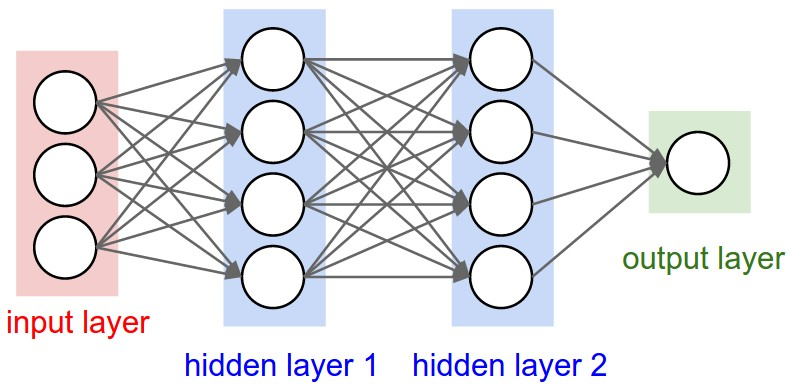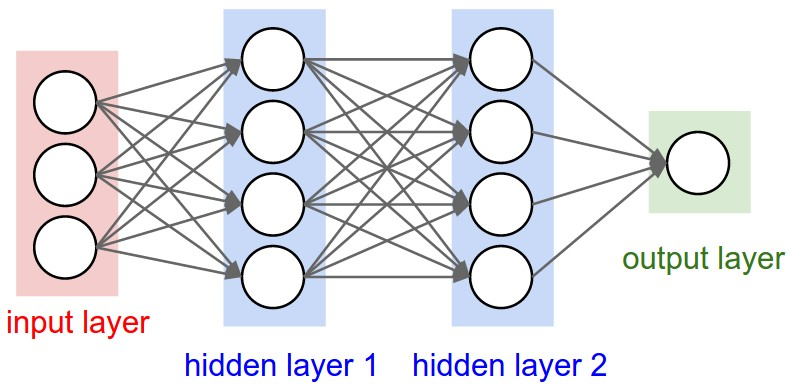

In [30]:
class MLP:
    def __init__(self, num_inputs, num_output_list):
        """
        num inputs: number of input neurons
        num_output_list: a list containing number of neurons in each layer after the input layer
        """
        sizes = [num_inputs] + num_output_list # sizes of all the layers in the MLP
        self.layers = []
        for i in range(len(sizes) - 1):
            self.layers.append(Layer(sizes[i], sizes[i+1]))

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

In [32]:
x = [2.0, 3.0, -1.0]
n = MLP(3, [4, 4, 1])
n(x)

Value(data=-0.9959425605064895)

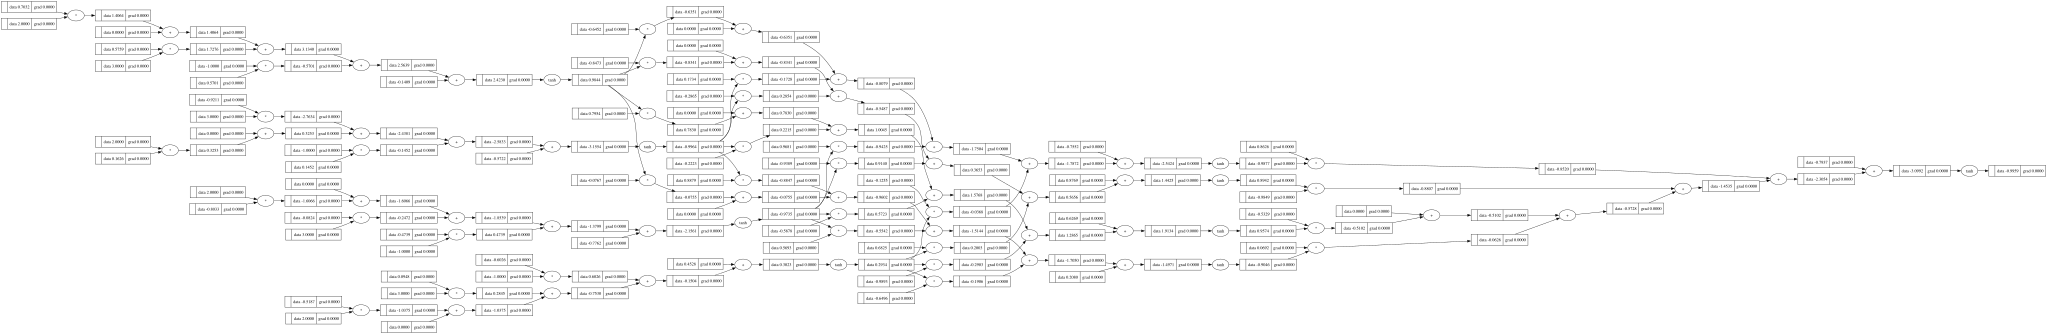

In [34]:
graph = MicrogradGraph()
graph.draw_dot(n(x))